# Problems
### Author: Aoife Flavin

## Problem1: Lady Tasting Tea Extended

This experiment is an extension of the Lady Tasting Tea Experiment conducted by Ronald A. Fisher.
In the original instance of the experiment the sample size consists of 8 cups of tea, 4 tea-first and 4 milk-first.

In this notebook I will look at what would happen if the sample size was 12, with 8 cups of tea-first and 4 cups of milk first.

In [23]:
# Mathematical functions from the standard library.
# https://docs.python.org/3/library/math.html
import math

# Permutations and combinations.
# https://docs.python.org/3/library/itertools.html
import itertools

# Random selections.
# https://docs.python.org/3/library/random.html
import random

# Numerical structures and operations.
# https://numpy.org/doc/stable/reference/index.html#reference
import numpy as np

# Plotting.
# https://matplotlib.org/stable/contents.html
import matplotlib.pyplot as plt

## Recap of 8-Cup Experiment

The original design of the experiment contained 8 cups, with half milk first and half tea-first.

The tea taster knows there are 4 tea-first cups and must decide which they are.
https://www.w3schools.com/python/ref_math_comb.asp

In [24]:
# Total number of cups.
recap_n = 8

# Number of tea-first cups.
recap_k = 4

# Number of different ways to choose 4 cups out of 8.
no_combs_8 = math.comb(recap_n, recap_k)

# Probability of selecting all correct cups by chance
p_all_correct_8 = 1 / no_combs_8

print("Number of combinations (8 cups):", no_combs_8)
print("Probability of all 8 cups being correct by chance:", p_all_correct_8)

Number of combinations (8 cups): 70
Probability of all 8 cups being correct by chance: 0.014285714285714285


## 12-Cup Experiment

For our new experiment we will change the design to use 12 cups in total, 8 of which will have the tea poured first and 4 which will have the milk poured first.

We are assuming the taster knows that 8 of the cups are tea-first and will try to pick out these cups.

#### Label the variables

In [25]:
# Number of cups of tea in total.
no_cups = 12

# Number of cups of tea with milk in first.
cups_milk_first = 4

# Number of cups of tea with tea in first.
cups_tea_first = 8


#### Use Math.comb to find the Probability that randomly all cups would be guessed correctly

Calculate the number of ways to choose k elements from a set of n elements where the order of the chosen elements does not matter and no element is selected more than once.

In [26]:
# Number of ways of selecting four cups from eight.
no_combs_12 = math.comb(no_cups, cups_tea_first)

# Probability of selecting all correct cups by chance
p_all_correct_12 = 1 / no_combs_12

print("Number of combinations (12 cups):", no_combs_12)
print("Probability of all 12 cups being correct by chance:", p_all_correct_12)

Number of combinations (12 cups): 495
Probability of all 12 cups being correct by chance: 0.00202020202020202


### Using NumPy to Simulate Random Guessing

Instead of only using the exact formula, we now simulate the experiment.

This means representing the true cups as a list of labels, where:
  - 1 = tea-first
  - 0 = milk-first

A random guess (under the null hypothesis) can be shown as a random permutation, in this case the participant knows how many tea-first/milk-first cups there are but has no real ability to distinguish them so we shuffle the labels randomly.

For each simulation:
  1. Shuffle the labels to represent a random guess.
  2. Check if the guessed arrangement matches the true arrangement exactly.

Sources:
- https://bookdown.org/kevin_davisross/probsim-book/introduction-to-simulation.html
- https://www.statology.org/how-to-generate-random-numbers-simulations-numpy/
- https://www.kdnuggets.com/numpy-simulating-random-processes-monte-carlo-methods
- https://numpy.org/doc/stable/reference/random/generated/numpy.random.permutation.html


In [27]:
# Define function, true labels = correct arrangement of cups, 1000 simulations
def estimate_all_correct(true_labels, no_sims=1000):
    
    #convert to numpy, start counter
    true_labels = np.array(true_labels)
    count_perfect = 0

    for _ in range(no_sims):
        # random permutation of the labels - null hypothesis
        guess = np.random.permutation(true_labels)

        # Check if all labels are the same as the true ones
        if np.array_equal(guess, true_labels):
            count_perfect += 1

    # amount of simulations with a perfect guess
    return count_perfect / no_sims

# True labels for the each experiment
true_labels_8 = [1]*4 + [0]*4      # 4 tea-first, 4 milk-first
true_labels_12 = [1]*8 + [0]*4     # 8 tea-first, 4 milk-first

# No. simulations
no_sims = 1000

# Estimate probabilities by simulation.
p_all_correct_8_sim = estimate_all_correct(true_labels_8, no_sims)
p_all_correct_12_sim = estimate_all_correct(true_labels_12, no_sims)

print("Simulated probability that all 8 cups are correct: ", p_all_correct_8_sim)
print("Exact     probability that all 8 cups are correct: ", p_all_correct_8)
print()
print("Simulated probability that all 12 cups are correct:", p_all_correct_12_sim)
print("Exact     probability that all 12 cups are correct:", p_all_correct_12)

Simulated probability that all 8 cups are correct:  0.015
Exact     probability that all 8 cups are correct:  0.014285714285714285

Simulated probability that all 12 cups are correct: 0.003
Exact     probability that all 12 cups are correct: 0.00202020202020202


# Interpreting Results

### Null vs Alternative Hypothesis
The Null Hypothesis in this case would mean that the tea taster is just guessing and she has no realy ability to tell the cups apart.

The Alternative Hypothesis would mean that the tea taster is not guessing and she has some ability to tell the cups apart.

**What the probabilities mean**

The Exact probabilities above represent the likelihood of getting a perfect score under the null hypothesis.
- 8-cup design - probability = 1/70 ≈ 0.0143
- 12-cup design - probability = 1/495 ≈ 0.002

**Statistical significance**

A p-value less than 0.05 is typically considered to be statistically significant, in which case the null hypothesis should be rejected

- Both probabilities are below 0.05 → a perfect score rejects the null hypothesis in either design.
- But 1/495 is much smaller than 1/70 → the 12-cup design gives stronger evidence in favor of the alternative hypothesis.

So if the tea taster gets every cup right in the 12-cup setup, it’s stronger evidence that they actually have the skill and are not just guessing.

Sources:
- https://www.investopedia.com/terms/p/p-value.asp 
- https://www.datacamp.com/doc/numpy/arange?dc_referrer=https%3A%2F%2Fwww.google.com%2F
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html


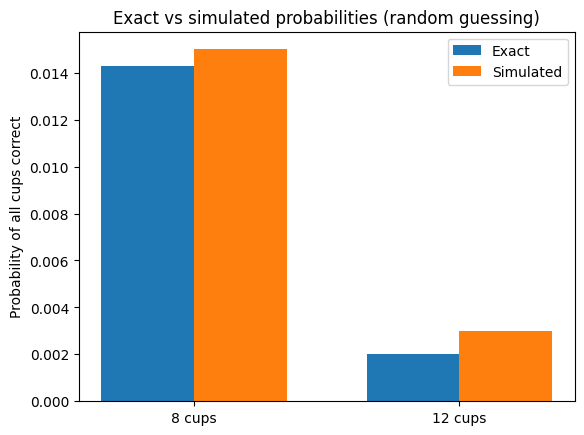

In [28]:
#Bar chart showing probability
labels = ["8 cups", "12 cups"]
exact = [p_all_correct_8, p_all_correct_12]
sim   = [p_all_correct_8_sim, p_all_correct_12_sim]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()

ax.bar(x - width/2, exact, width, label="Exact")
ax.bar(x + width/2, sim,   width, label="Simulated")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Probability of all cups correct")
ax.set_title("Exact vs simulated probabilities (random guessing)")
ax.legend();

plt.show()

# Assignment no.2 Normal Distribution

For this problem we will generate 100,000 samples of size 10 from the standard normal distribution. For each sample, compute 
- the sample standard deviation (ddof=1)
- the population standard deviation (ddof=0). 

I will then plot histograms of both sets of values on the same axes, sescribe any differences and explain how these differences are expected to change if the sample size is increased.

In [29]:
# Binomial distribution.
import numpy as np

# Plotting.
import matplotlib.pyplot as plt

# Statistics.
import scipy.stats as stats

# Statistical models.
import statsmodels as sm

In [30]:
#no of samples (times we repeat the experiment)
no_samples = 100000

# Sample size
s_size = 10

#Standard Normal Distribution
mu = 0
sigma = 1

## Generate the Data

generate all the data in one go as a 2d numpy array

Sources:
- https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html
- 

In [31]:
# 100k samples, each of length 10
data = np.random.normal(loc=mu, scale=sigma, size=(no_samples, s_size))

print(data.shape)   # (100000, 10)


(100000, 10)


## Calculate the stadard deviation for each sample

NumPy's np.std has a parameter 'ddof' = "delta degrees of freedom".

ddof = 0  --> population standard deviation (divide by n)

ddof = 1  --> sample standard deviation    (divide by n - 1)

We want to compute the standard deviation of each row (each sample), so set axis=1

Sources:
- https://medium.com/@bluewall_46049/standard-deviation-variance-2424395a13be
- https://www.geeksforgeeks.org/python/numpy-std-in-python/
- https://numpy.org/devdocs/reference/generated/numpy.std.html

In [32]:
# sample standard dev: ddof = 1
sd_sample = np.std(data, axis=1, ddof=1)

# Population standard dev: ddof = 0
sd_population = np.std(data, axis=1, ddof=0)

# basic info
print("Sample SD (ddof=1):")
print("  mean:", np.mean(sd_sample))
print("  std of SDs:", np.std(sd_sample))

print("Population SD (ddof=0):")
print("  mean:", np.mean(sd_population))
print("  std of SDs:", np.std(sd_population))

Sample SD (ddof=1):
  mean: 0.9732511359293177
  std of SDs: 0.232557462114422
Population SD (ddof=0):
  mean: 0.9233070974648341
  std of SDs: 0.22062338014496724


## Plot the Histogram


### Sources: 
- https://www.geeksforgeeks.org/python/how-to-change-the-transparency-of-a-graph-plot-in-matplotlib-with-python/
- https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.axvline.html

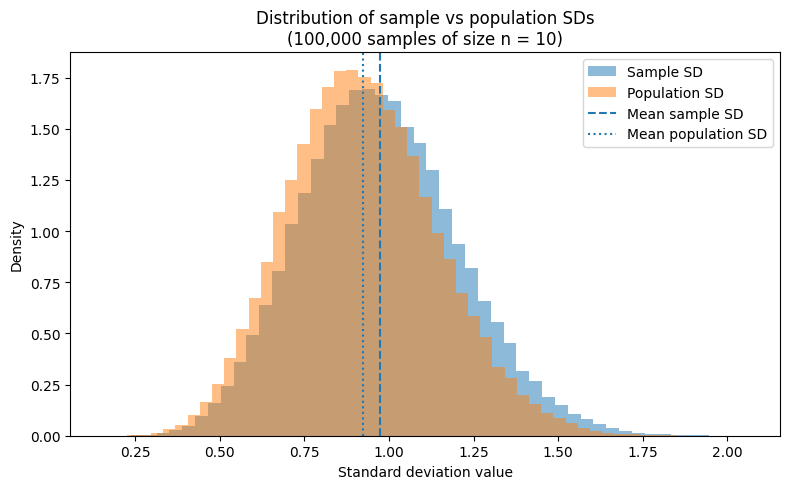

In [33]:
#Create the graph
fig, ax = plt.subplots(figsize=(8, 5))

#Histogram for sample SD
ax.hist(sd_sample, bins=50, density=True, alpha=0.5, label="Sample SD")
#Histogram for population SD
ax.hist(sd_population, bins=50, density=True, alpha=0.5, label="Population SD")

#Lines for the means of each distrbution
ax.axvline(np.mean(sd_sample), linestyle="--", label="Mean sample SD")
ax.axvline(np.mean(sd_population), linestyle=":", label="Mean population SD")

ax.set_xlabel("Standard deviation value")
ax.set_ylabel("Density")
ax.set_title(f"Distribution of sample vs population SDs\n({no_samples:,} samples of size n = {s_size})")
ax.legend()

plt.tight_layout()
plt.show()


### What differences do we see?

When you look at the two histograms you should see:

The sample SD histogram is slightly shifted to the right meaning its values are usually a bit larger than the population SD values.

Both histograms are centred near 1 due to the true standard deviation of the data we sampled being 1.

The histogram for the population SD (ddof=0) is slightly too far left, it tends to give values a bit smaller than 1 on average, meaning it underestimates the real spread.

The sample SD histogram (ddof=1) is closer to the correct centre, its average is nearer the true value of 1, so it gives a better estimate, especially with small samples like 
s_size = 10

This is why the sample standard deviation (ddof=1) is preferred: its histogram shows it is less biased.

### What happens if we increase the sample size?

If we redraw the histograms using bigger samples (like s_size=30, s_size=100, etc.):

Both histograms become narrower, meaning the SD estimates vary less and cluster tightly around 1.

Both histograms move closer together. The difference between ddof=0 and ddof=1 becomes very small.

When sample size is large dividing by n or n-1 makes almost no difference, the bias gets harder to see.

So:

For small samples, the histograms clearly show the difference: ddof=1 lines up better with the true value.

For large samples, the histograms almost overlap, meaning both formulas give nearly the same result.

### Sources:
- https://bookdown.org/a_shaker/STM1001_Topic_2/2.1-variance-and-standard-deviation.html
- https://www.youtube.com/watch?v=lwfAJM3KZCE
- https://statisticsbyjim.com/basics/standard-deviation/


# Problem 3: t-tests

A type II error occurs when a test fails to reject the null hypothesis even though it is false. For each mean difference 
d=0, 0.1, 0.2, …, 1.0, repeat the following simulation 1,000 times:

1. Draw two samples of size 100, one from the standard normal distribution and one from the normal distribution with mean d and standard deviation 1.
2. Run an independent samples t-test on the two samples, rejecting the null hypothesis if the p-value is less than 0.05.
3. Record the proportion of times the null hypothesis is not rejected.

Plot this proportion against d, and explain how the type II error rate changes as the difference in means increases.

In [34]:
# Numerical arrays.
import numpy as np

# Statistical functions.
import scipy.stats as stats

# Plotting.
import matplotlib.pyplot as plt

# Statistical plots.
import seaborn as sns

## Set simulation parameters

- `n` is the sample size per group  
- `reps` is the number of repeated simulations for each value of \(d\)  
- `alpha` is the significance level (reject if \(p < 0.05\))

In [35]:
n = 100
reps = 1000
alpha = 0.05

## Define the range of mean differences

We are looking at differences from 0 to 1, in steps of 0.1.

https://numpy.org/devdocs/reference/generated/numpy.arange.html

In [36]:
ds = np.arange(0, 1.1, 0.1)
ds

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

## Run the simulation

For each value of d, we repeat the same experiment many times.

In each repetition:

1. Randomly generate one sample from a normal distribution - mean = 0, sd = 1.
2. Randomly generate a second sample from a normal distribution with mean = d, sd = 1.
3. Compare the samples using an independent samples t-test.

If the p-value is greater than or equal to 0.05, we do not reject the null hypothesis and record this outcome.

After repeating this process 1,000 times, we calculate the proportion of times the null hypothesis was not rejected.
This proportion estimates the type II error rate for that value of d.



### Sources: 
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html
- https://numiqo.com/tutorial/t-test
- https://en.wikipedia.org/wiki/Student%27s_t-test

In [37]:
# Empty list
type2_errors = []

# For loop - mean differences
for d in ds:
    not_reject = 0
    
    for i in range(reps):
        # Draw a sample from N(0, 1)
        group_a = np.random.normal(0, 1, n)
        # Draw a sample from N(d, 1)
        group_b = np.random.normal(d, 1, n)
        
        # Independent samples t-test
        ttest = stats.ttest_ind(group_a, group_b)
        
        # If the p-value is greater than or equal to alpha, do not reject the null hypothesis
        if ttest.pvalue >= alpha:
            not_reject += 1
    
    # Calculate the no of non-rejections
    type2_errors.append(not_reject / reps)

type2_errors

[0.947, 0.921, 0.712, 0.448, 0.202, 0.055, 0.006, 0.002, 0.0, 0.0, 0.0]

## Plot it 

Plot the estimated type II error rate (the proportion of non-rejections) against \(d\).

### Sources:
- https://seaborn.pydata.org/generated/seaborn.lineplot.html

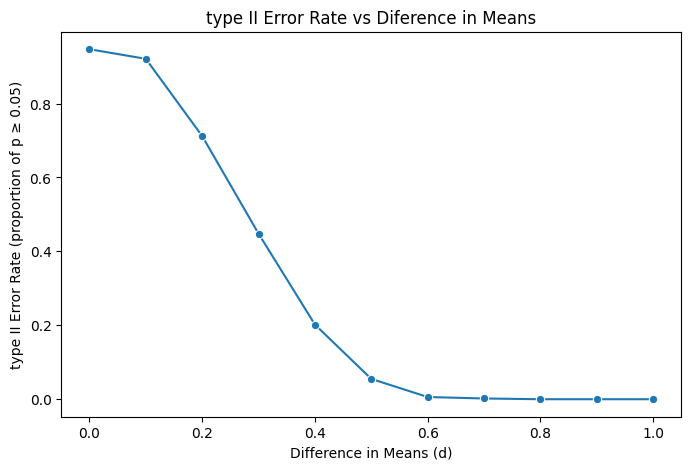

In [38]:
plt.figure(figsize=(8, 5))
sns.lineplot(x=ds, y=type2_errors, marker="o")

plt.xlabel("Difference in Means (d)")
plt.ylabel("type II Error Rate (proportion of p ≥ 0.05)")
plt.title("type II Error Rate vs Diference in Means")

plt.show()

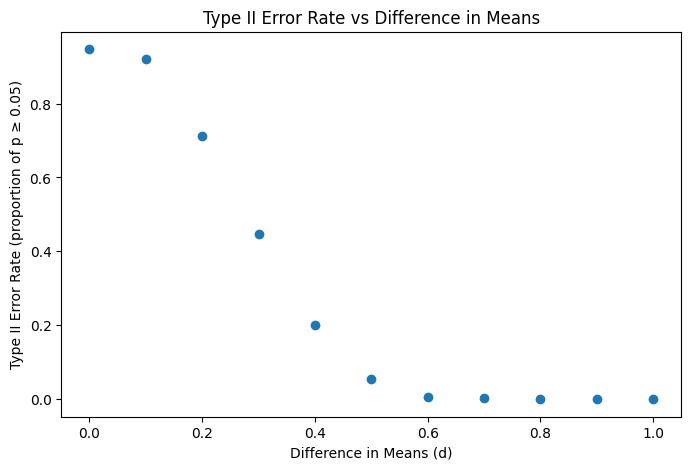

In [39]:
plt.figure(figsize=(8, 5))
plt.scatter(ds, type2_errors)

plt.xlabel("Difference in Means (d)")
plt.ylabel("Type II Error Rate (proportion of p ≥ 0.05)")
plt.title("Type II Error Rate vs Difference in Means")

plt.show()

## Short-answer explanation of the plot

As the difference between the two group means gets bigger, it becomes easier for the t-test to notice that the groups are different.

When the difference is very small (or zero), the two groups look similar, so the test can ofte fail to reject the null hypothesis. This means we often miss real differences when they are small.

As the difference increases, the test rejects the null hypothesis more often, so the chance of missing a real difference decreases.

Therefore, the type II error rate decreases as the mean difference increases.

### Sources: 
- https://online.stat.psu.edu/stat200/lesson/6/6.5
- http://www.stat.ucla.edu/~frederic/13/F18/13day05.pdf

# ANOVA

Generate three independent samples, each of size 30, from normal distributions with means 0, 0.5, and 1, each with standard deviation 1.

Perform a one-way ANOVA to test whether all three means are equal.

Perform three independent two-sample t-tests: samples 1 vs 2, 1 vs 3, and 2 vs 3.

Compare the conclusions.

Write a short note on why ANOVA is preferred over running several t-tests.

In [40]:
# Numerical arrays.
import numpy as np

# Plotting.
import matplotlib.pyplot as plt

# Statistical functions.
import scipy.stats as stats

# Mathematical functions.
import math

# Data frames.
import pandas as pd

# Combinations and permutations.
import itertools as it

## Generate the samples

generate three samples, size = 30, normal distributions:
- Sample 1: mean 0, std 1
- Sample 2: mean 0.5, std 1
- Sample 3: mean 1, std 

### Sources: 
- https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html

In [41]:
# Sample size.
n = 30

# Generate the samples.
sample_1 = np.random.normal(loc=0.0, scale=1.0, size=n)
sample_2 = np.random.normal(loc=0.5, scale=1.0, size=n)
sample_3 = np.random.normal(loc=1.0, scale=1.0, size=n)

# Show
sample_1[:5], sample_2[:5], sample_3[:5]

(array([-1.40037501, -0.41208193, -0.39414375, -1.19999567,  1.29255227]),
 array([-0.71197126, -0.7712544 , -1.5573011 ,  0.19403213, -0.24192436]),
 array([0.69265374, 0.8165922 , 0.95205852, 1.42272658, 1.5978467 ]))

## One way ANOVA

Null Hypothesis (H0): all 3 population means are equal

Alternative hypothesis (H1): one mean is different

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html

In [42]:
# one-way ANOVA.
f_statistic, p_value = stats.f_oneway(sample_1, sample_2, sample_3)

# Show.
f_statistic, p_value

(np.float64(6.195811957373511), np.float64(0.0030505052761720212))

### ANOVA conclusion (using α = 0.05)

- If p_value < 0.05, we reject H0 (evidence that not all means are equal). Meaning that the observed differences between sample means are too large to be explained by random chance alone
- Otherwise, we do not reject H0. Meaning that the differences between the sample means are small enough that they could reasonably occur due to randomness

#### SOurces: 
- https://www.investopedia.com/terms/p/p-value.asp

In [43]:
# True or False?
alpha = 0.05
p_value < alpha

np.True_

## T-Tests

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html


In [44]:
# Test 1 v 2
t1_2, p1_2 = stats.ttest_ind(sample_1, sample_2)
# Test 1 v 3
t1_3, p1_3 = stats.ttest_ind(sample_1, sample_3)
# Test 2 v 3
t2_3, p2_3 = stats.ttest_ind(sample_2, sample_3)

# Show
(t1_2, p1_2), (t1_3, p1_3), (t2_3, p2_3)

((np.float64(-1.4311863436091237), np.float64(0.1577432212480155)),
 (np.float64(-3.8874167532583557), np.float64(0.00026303324503442453)),
 (np.float64(-1.936712821601102), np.float64(0.05765709492245522)))